In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("transactions.csv")
df.head()

,customer_id,order_id,order_date,order_amount
0,C1057,O10253,2023-01-01,175.77
1,C1103,O10459,2023-01-01,395.21
2,C1255,O11163,2023-01-02,212.23
3,C1108,O10485,2023-01-02,150.42
4,C1196,O10884,2023-01-03,33.33


In [3]:
df.shape

(1372, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   1372 non-null   object        
 1   order_id      1372 non-null   object        
 2   order_date    1372 non-null   datetime64[ns]
 3   order_amount  1372 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 43.0+ KB


In [6]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [8]:
df["order_amount"].sum()

np.float64(410919.21)

In [9]:
df["customer_id"].nunique()

300

In [10]:
df["order_amount"].mean()

np.float64(299.5037973760933)

In [11]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days = 1)

In [12]:
rfm = df.groupby("customer_id").agg({
    "order_date" : lambda x : (snapshot_date - x.max()).days,
    "order_id" : "count",
    "order_amount" : "mean"
}).reset_index()

rfm.columns = ["customer_id", "recency" , "frequency" , "avg_order_value"]

rfm.head()

,customer_id,recency,frequency,avg_order_value
0,C1000,69,5,410.510
1,C1001,31,6,255.545
2,C1002,343,3,360.400
3,C1003,254,5,383.682
4,C1004,29,5,131.254


In [13]:
ltv = df.groupby("customer_id")["order_amount"].sum().reset_index()
ltv.columns = ["customer_id", "ltv"]
ltv.head()

,customer_id,ltv
0,C1000,2052.55
1,C1001,1533.27
2,C1002,1081.20
3,C1003,1918.41
4,C1004,656.27


In [14]:
data = pd.merge(rfm, ltv, on = "customer_id")
data.head()

,customer_id,recency,frequency,avg_order_value,ltv
0,C1000,69,5,410.510,2052.55
1,C1001,31,6,255.545,1533.27
2,C1002,343,3,360.400,1081.20
3,C1003,254,5,383.682,1918.41
4,C1004,29,5,131.254,656.27


In [16]:
data.corr(numeric_only=True)

,recency,frequency,avg_order_value,ltv
recency,1.000000,-0.351145,0.041563,-0.264064
frequency,-0.351145,1.000000,-0.050716,0.748755
avg_order_value,0.041563,-0.050716,1.000000,0.565123
ltv,-0.264064,0.748755,0.565123,1.000000


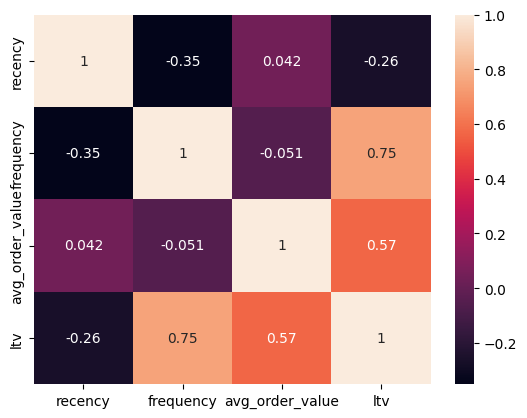

In [17]:
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

Building machine learning model

In [19]:
x = data[["recency", "frequency", "avg_order_value"]]
y = data["ltv"]

In [20]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

making predictions

In [22]:
y_pred = model.predict(x_test)

Evaluating model

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE :", mae)
print("RMSE :", rmse)

MAE : 133.15564618069973
RMSE : 254.90355275296693


Comparing actual vs predicted

In [24]:
comparison = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})

comparison.head()

,Actual,Predicted
203,1538.75,1531.196848
266,2345.80,2155.536519
152,1207.65,1787.410887
9,539.12,457.327472
233,1000.16,1097.394794


Prediction Performance

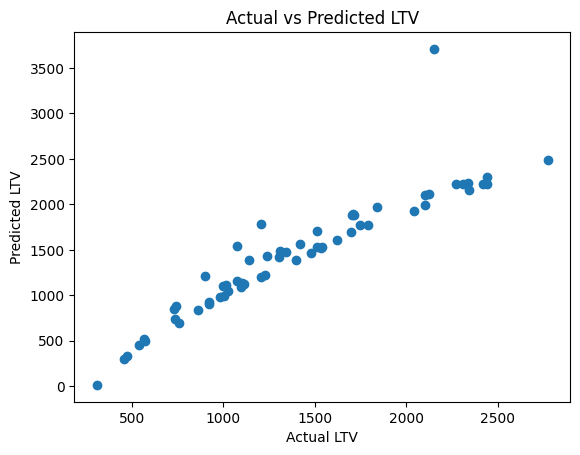

In [26]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV")
plt.show()

training XGBoost Model

In [28]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.05,
    max_depth = 4,
    random_state = 42
)

xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

Evaluating XGBoost

In [29]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost MAE : ", mae_xgb)
print("XGBoost RMSE : ", rmse_xgb)

XGBoost MAE :  46.00762679036459
XGBoost RMSE :  116.12094803938534


predict LTV for all customers

In [30]:
data["predicted_ltv"] = xgb_model.predict(x)

Customer Segmentation - we divide customers into 3 groups

In [31]:
data["segment"] = pd.qcut(
    data["predicted_ltv"],
    q = 3,
    labels = ["Low Value", "Medium Value", "High Value"]
)

In [32]:
data["segment"].value_counts()

,count
segment,
Low Value,100
Medium Value,100
High Value,100


In [33]:
data.to_csv("final_ltv_predictions.csv", index=False)